# **LIBRARY KRIPENDOOF**

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — Install library & Upload file
# ═══════════════════════════════════════════════════════════════
!pip install krippendorff

from google.colab import files
uploaded = files.upload()  # Pilih file: Labelling_Skripsweet_-_Fiinal.csv

Saving Labelling Skripsweet - Fiinal.csv to Labelling Skripsweet - Fiinal.csv


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — Hitung IAA dengan library krippendorff
# ═══════════════════════════════════════════════════════════════
import csv
import numpy as np
import krippendorff
from collections import Counter

CSV_PATH   = "Labelling_Skripsweet_-_Fiinal.csv"
ANNOTATORS = ["jihan", "kakak", "reza"]
ASPEKS     = ["aspek1", "aspek2", "aspek3"]

# Library krippendorff pakai np.nan untuk nilai kosong/null
LABEL_MAP = {
    "positif": 1,
    "negatif": 2,
    "netral" : 3,
    "-"      : np.nan,
    ""       : np.nan,
}

def encode_label(label: str):
    return LABEL_MAP.get(str(label).strip().lower(), np.nan)

def load_csv(filepath):
    with open(filepath, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))

def build_matrix_for_library(rows, aspek):
    """
    Library krippendorff butuh matriks shape (n_annotators x n_items)
    dan pakai np.nan untuk non-response — berbeda dari versi manual.
    """
    mat = np.full((len(ANNOTATORS), len(rows)), np.nan)
    for j, ann in enumerate(ANNOTATORS):
        for i, row in enumerate(rows):
            val = row.get(f"{ann}_{aspek}", "") or ""
            mat[j, i] = encode_label(val)
    return mat

def interpret_alpha(alpha):
    if alpha >= 0.80:
        return "✅ Sangat baik  (reliable)"
    elif alpha >= 0.667:
        return "🟡 Cukup        (tentative conclusions)"
    elif alpha >= 0.40:
        return "🟠 Lemah        (perlu revisi panduan anotasi)"
    else:
        return "🔴 Buruk        (perlu re-training annotator)"


In [ ]:
# ── MAIN ───────────────────────────────────────────────────────
rows = load_csv(CSV_PATH)

print(f"{'═'*60}")
print("  INTER-ANNOTATOR AGREEMENT — Krippendorff's Alpha")
print("  (menggunakan library: krippendorff)")
print(f"{'═'*60}")
print(f"  File       : {CSV_PATH}")
print(f"  Annotator  : {', '.join(a.upper() for a in ANNOTATORS)}")
print(f"  Aspek      : {', '.join(a.upper() for a in ASPEKS)}")
print(f"  Label valid: Positif | Negatif | Netral")
print(f"  Total item : {len(rows)}")

results = {}
for aspek in ASPEKS:
    print(f"\n{'─'*50}")
    print(f"  ASPEK : {aspek.upper()}")
    print(f"{'─'*50}")

    mat   = build_matrix_for_library(rows, aspek)
    alpha = krippendorff.alpha(
        reliability_data=mat,
        level_of_measurement="nominal"  # karena label kategorik
    )
    results[aspek] = alpha
    print(f"  Krippendorff's Alpha = {alpha:.4f}   {interpret_alpha(alpha)}")

════════════════════════════════════════════════════════════
  INTER-ANNOTATOR AGREEMENT — Krippendorff's Alpha
  (menggunakan library: krippendorff)
════════════════════════════════════════════════════════════
  File       : Labelling_Skripsweet_-_Fiinal.csv
  Annotator  : JIHAN, KAKAK, REZA
  Aspek      : ASPEK1, ASPEK2, ASPEK3
  Label valid: Positif | Negatif | Netral
  Total item : 1699

──────────────────────────────────────────────────
  ASPEK : ASPEK1
──────────────────────────────────────────────────
  Krippendorff's Alpha = 0.8679   ✅ Sangat baik  (reliable)

──────────────────────────────────────────────────
  ASPEK : ASPEK2
──────────────────────────────────────────────────
  Krippendorff's Alpha = 0.8884   ✅ Sangat baik  (reliable)

──────────────────────────────────────────────────
  ASPEK : ASPEK3
──────────────────────────────────────────────────
  Krippendorff's Alpha = 0.8886   ✅ Sangat baik  (reliable)


In [ ]:
# ── Ringkasan ──────────────────────────────────────────────────
print(f"\n{'═'*60}")
print("  REKAPITULASI KRIPPENDORFF'S ALPHA")
print(f"{'═'*60}")
print(f"  {'Aspek':<12}  {'Alpha':>8}   Interpretasi")
print(f"  {'─'*12}  {'─'*8}   {'─'*30}")
for aspek, alpha in results.items():
    print(f"  {aspek.upper():<12}  {alpha:>8.4f}   {interpret_alpha(alpha)}")

valid = [a for a in results.values() if a is not None]
avg   = sum(valid) / len(valid)
print(f"\n  Rata-rata Alpha    : {avg:.4f}   {interpret_alpha(avg)}")
print()


════════════════════════════════════════════════════════════
  REKAPITULASI KRIPPENDORFF'S ALPHA
════════════════════════════════════════════════════════════
  Aspek            Alpha   Interpretasi
  ────────────  ────────   ──────────────────────────────
  ASPEK1          0.8679   ✅ Sangat baik  (reliable)
  ASPEK2          0.8884   ✅ Sangat baik  (reliable)
  ASPEK3          0.8886   ✅ Sangat baik  (reliable)

  Rata-rata Alpha    : 0.8816   ✅ Sangat baik  (reliable)



# **INI PAKAI 2 TAHAP MODEL**

In [ ]:
!pip install PySastrawi scikit-learn pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 7.4 MB/s eta 0:00:00


In [ ]:
# ── 2. Import ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

In [ ]:
# ── 3. Load Data ─────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()

filename  = 'Labelling_Skripsweet_-_FIX.csv'
df_raw    = pd.read_csv(filename)
print(f'✅ Data dimuat: {df_raw.shape[0]} baris')
print(df_raw[['tanpa_stemming','final_aspek1','final_aspek2','final_aspek3']].head(5))

Saving Labelling_Skripsweet_-_FIX.csv to Labelling_Skripsweet_-_FIX.csv
✅ Data dimuat: 1699 baris
                                      tanpa_stemming final_aspek1  \
0         setiap mau masuk ke beranda selalu loading          NaN   
1                       aplikasi rumah sakit terbaik          NaN   
2  aplikasi lengkap fitur andalan dan sangat info...          NaN   
3               sangat memudahkan terimakasih siloam          NaN   
4                                    mudah dan cepat          NaN   

  final_aspek2 final_aspek3  
0          NaN      Negatif  
1          NaN      Positif  
2          NaN      Positif  
3          NaN      Positif  
4          NaN      Positif  


In [ ]:
# ── 4. Stemming ──────────────────────────────────────────────
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def apply_stemming(text):
    return stemmer.stem(str(text)) if pd.notna(text) else ''

print('\nMenerapkan stemming...')
df_raw['ulasan_stem'] = df_raw['tanpa_stemming'].apply(apply_stemming)
print('✅ Stemming selesai!')


Menerapkan stemming...
✅ Stemming selesai!


In [ ]:
# ── 5. Fungsi Training 2 Tahap ────────────────────────────────
def train_pipeline_aspek(df, aspek_col, text_col='ulasan_stem',
                         test_size=0.1, random_state=42):
    """
    Melatih 2 model SVM per aspek (referensi: GeeksforGeeks Multiclass SVM):

    Model A — Relevansi  : SVM dengan decision_function_shape='ovo'
                           Label: Relevan / Tidak Relevan

    Model B — Sentimen   : SVM dengan decision_function_shape='ovo'
                           Label: Positif / Negatif / Netral
                           (hanya dari data yang Relevan)
    """
    print(f'\n{"="*60}')
    print(f'  TRAINING: {aspek_col.upper()}')
    print(f'{"="*60}')

    valid_sentimen = ['Positif', 'Negatif', 'Netral']
    df = df.copy()

    # Buat label relevansi
    df['relevansi'] = df[aspek_col].apply(
        lambda x: 'Relevan' if x in valid_sentimen else 'Tidak Relevan'
    )

    print(f'\n  Distribusi Relevansi  : {df["relevansi"].value_counts().to_dict()}')

    # ════════════════════════════════════════════════════════
    # MODEL A — RELEVANSI (binary: Relevan vs Tidak Relevan)
    # ════════════════════════════════════════════════════════
    X_rel       = df[text_col]
    y_rel       = df['relevansi']

   # Split 90/10
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_rel_tfidf, y_rel,
        test_size=test_size,
        random_state=random_state,
        stratify=y_rel
    )

    tfidf_rel   = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=1)
    X_rel_tfidf = tfidf_rel.fit_transform(X_rel)

    # Hitung class weight → naikkan bobot Relevan
    from sklearn.utils.class_weight import compute_class_weight
    classes_r = np.unique(y_train_r)
    weights_r = compute_class_weight(class_weight='balanced', classes=classes_r, y=y_train_r)
    cw_rel    = dict(zip(classes_r, weights_r))
    cw_rel['Relevan'] *= 2.5

    # SVM OvO untuk relevansi
    svm_rel = SVC(
        kernel='linear',
        C=1.0,
        decision_function_shape='ovo',   # One-vs-One (GeeksforGeeks ref)
        random_state=random_state,
        class_weight=cw_rel
    )
    svm_rel.fit(X_train_r, y_train_r)

    y_pred_r  = svm_rel.predict(X_test_r)
    acc_r     = accuracy_score(y_test_r, y_pred_r)
    f1_r      = f1_score(y_test_r, y_pred_r, average='weighted')
    prec_r    = precision_score(y_test_r, y_pred_r, average='weighted')
    rec_r     = recall_score(y_test_r, y_pred_r, average='weighted')

    print(f'\n  ── Model A: Relevansi (OvO SVM) ──')
    print(f'  Data Train : {X_train_r.shape[0]} | Data Test : {X_test_r.shape[0]}')
    print(f'  Fitur TF-IDF : {X_train_r.shape[1]}')
    print(f'  Accuracy   : {acc_r*100:.2f}%')
    print(f'  Precision  : {prec_r*100:.2f}%')
    print(f'  Recall     : {rec_r*100:.2f}%')
    print(f'  F1-Score   : {f1_r*100:.2f}%')
    print(f'\n{classification_report(y_test_r, y_pred_r)}')

    # ════════════════════════════════════════════════════════
    # MODEL B — SENTIMEN (multiclass: Positif/Negatif/Netral)
    # ════════════════════════════════════════════════════════
    df_relevan = df[df[aspek_col].isin(valid_sentimen)].copy()
    print(f'  Distribusi Sentimen   : {df_relevan[aspek_col].value_counts().to_dict()}')

    X_sen       = df_relevan[text_col]
    y_sen       = df_relevan[aspek_col].str.strip()

    tfidf_sen   = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=1)
    X_sen_tfidf = tfidf_sen.fit_transform(X_sen)

    # Split 90/10
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X_sen_tfidf, y_sen,
        test_size=test_size,
        random_state=random_state,
        stratify=y_sen
    )

    # SVM OvO untuk sentimen multiclass
    svm_sen = SVC(
        kernel='linear',
        C=1.0,
        decision_function_shape='ovo',   # One-vs-One (GeeksforGeeks ref)
        random_state=random_state,
        class_weight='balanced'
    )
    svm_sen.fit(X_train_s, y_train_s)

    y_pred_s  = svm_sen.predict(X_test_s)
    acc_s     = accuracy_score(y_test_s, y_pred_s)
    f1_s      = f1_score(y_test_s, y_pred_s, average='weighted')
    prec_s    = precision_score(y_test_s, y_pred_s, average='weighted')
    rec_s     = recall_score(y_test_s, y_pred_s, average='weighted')

    print(f'\n  ── Model B: Sentimen (OvO SVM Multiclass) ──')
    print(f'  Data Train : {X_train_s.shape[0]} | Data Test : {X_test_s.shape[0]}')
    print(f'  Fitur TF-IDF : {X_train_s.shape[1]}')
    print(f'  Accuracy   : {acc_s*100:.2f}%')
    print(f'  Precision  : {prec_s*100:.2f}%')
    print(f'  Recall     : {rec_s*100:.2f}%')
    print(f'  F1-Score   : {f1_s*100:.2f}%')
    print(f'\n{classification_report(y_test_s, y_pred_s)}')

    return {
        # Model A
        'model_relevansi'  : svm_rel,
        'tfidf_relevansi'  : tfidf_rel,
        'y_test_rel'       : y_test_r,
        'y_pred_rel'       : y_pred_r,
        'acc_relevansi'    : acc_r,
        'f1_relevansi'     : f1_r,
        'prec_relevansi'   : prec_r,
        'rec_relevansi'    : rec_r,
        'labels_relevansi' : ['Relevan', 'Tidak Relevan'],
        # Model B
        'model_sentimen'   : svm_sen,
        'tfidf_sentimen'   : tfidf_sen,
        'y_test_sen'       : y_test_s,
        'y_pred_sen'       : y_pred_s,
        'acc_sentimen'     : acc_s,
        'f1_sentimen'      : f1_s,
        'prec_sentimen'    : prec_s,
        'rec_sentimen'     : rec_s,
        'labels_sentimen'  : sorted(y_sen.unique()),
    }

In [ ]:
# ── 6. Training Semua Aspek ───────────────────────────────────
pipeline = {}
pipeline['Aspek 1'] = train_pipeline_aspek(df_raw, 'final_aspek1')
pipeline['Aspek 2'] = train_pipeline_aspek(df_raw, 'final_aspek2')
pipeline['Aspek 3'] = train_pipeline_aspek(df_raw, 'final_aspek3')
print('\n✅ Semua model selesai ditraining!')


  TRAINING: FINAL_ASPEK1

  Distribusi Relevansi  : {'Tidak Relevan': 1246, 'Relevan': 453}

  ── Model A: Relevansi (OvO SVM) ──
  Data Train : 1529 | Data Test : 170
  Fitur TF-IDF : 5000
  Accuracy   : 84.71%
  Precision  : 84.94%
  Recall     : 84.71%
  F1-Score   : 84.81%

               precision    recall  f1-score   support

      Relevan       0.70      0.73      0.72        45
Tidak Relevan       0.90      0.89      0.90       125

     accuracy                           0.85       170
    macro avg       0.80      0.81      0.81       170
 weighted avg       0.85      0.85      0.85       170

  Distribusi Sentimen   : {'Positif': 253, 'Negatif': 198, 'Netral': 2}

  ── Model B: Sentimen (OvO SVM Multiclass) ──
  Data Train : 407 | Data Test : 46
  Fitur TF-IDF : 5000
  Accuracy   : 93.48%
  Precision  : 93.60%
  Recall     : 93.48%
  F1-Score   : 93.49%

              precision    recall  f1-score   support

     Negatif       0.90      0.95      0.93        20
     Positi

In [ ]:
# ── 7. Ringkasan Hasil ────────────────────────────────────────
nama_aspek = {
    'Aspek 1': 'Fitur Medis Aplikasi',
    'Aspek 2': 'Pelayanan & Kepuasan',
    'Aspek 3': 'Teknis Aplikasi'
}

print(f'\n{"="*70}')
print(f'  RINGKASAN HASIL TRAINING — SVM One-vs-One (OvO)')
print(f'{"="*70}')
print(f'  {"Aspek":<22} {"Model":<12} {"Accuracy":>10} {"Precision":>10} {"Recall":>8} {"F1":>8}')
print(f'  {"─"*22} {"─"*12} {"─"*10} {"─"*10} {"─"*8} {"─"*8}')
for aspek, res in pipeline.items():
    print(f'  {nama_aspek[aspek]:<22} {"Relevansi":<12} '
          f'{res["acc_relevansi"]*100:>9.2f}% '
          f'{res["prec_relevansi"]*100:>9.2f}% '
          f'{res["rec_relevansi"]*100:>7.2f}% '
          f'{res["f1_relevansi"]*100:>7.2f}%')
    print(f'  {"":<22} {"Sentimen":<12} '
          f'{res["acc_sentimen"]*100:>9.2f}% '
          f'{res["prec_sentimen"]*100:>9.2f}% '
          f'{res["rec_sentimen"]*100:>7.2f}% '
          f'{res["f1_sentimen"]*100:>7.2f}%')
    print(f'  {"─"*70}')



  RINGKASAN HASIL TRAINING — SVM One-vs-One (OvO)
  Aspek                  Model          Accuracy  Precision   Recall       F1
  ────────────────────── ──────────── ────────── ────────── ──────── ────────
  Fitur Medis Aplikasi   Relevansi        84.71%     84.94%   84.71%   84.81%
                         Sentimen         93.48%     93.60%   93.48%   93.49%
  ──────────────────────────────────────────────────────────────────────
  Pelayanan & Kepuasan   Relevansi        90.00%     90.16%   90.00%   90.00%
                         Sentimen         91.57%     92.27%   91.57%   90.69%
  ──────────────────────────────────────────────────────────────────────
  Teknis Aplikasi        Relevansi        84.12%     86.42%   84.12%   84.21%
                         Sentimen         84.51%     84.83%   84.51%   84.42%
  ──────────────────────────────────────────────────────────────────────


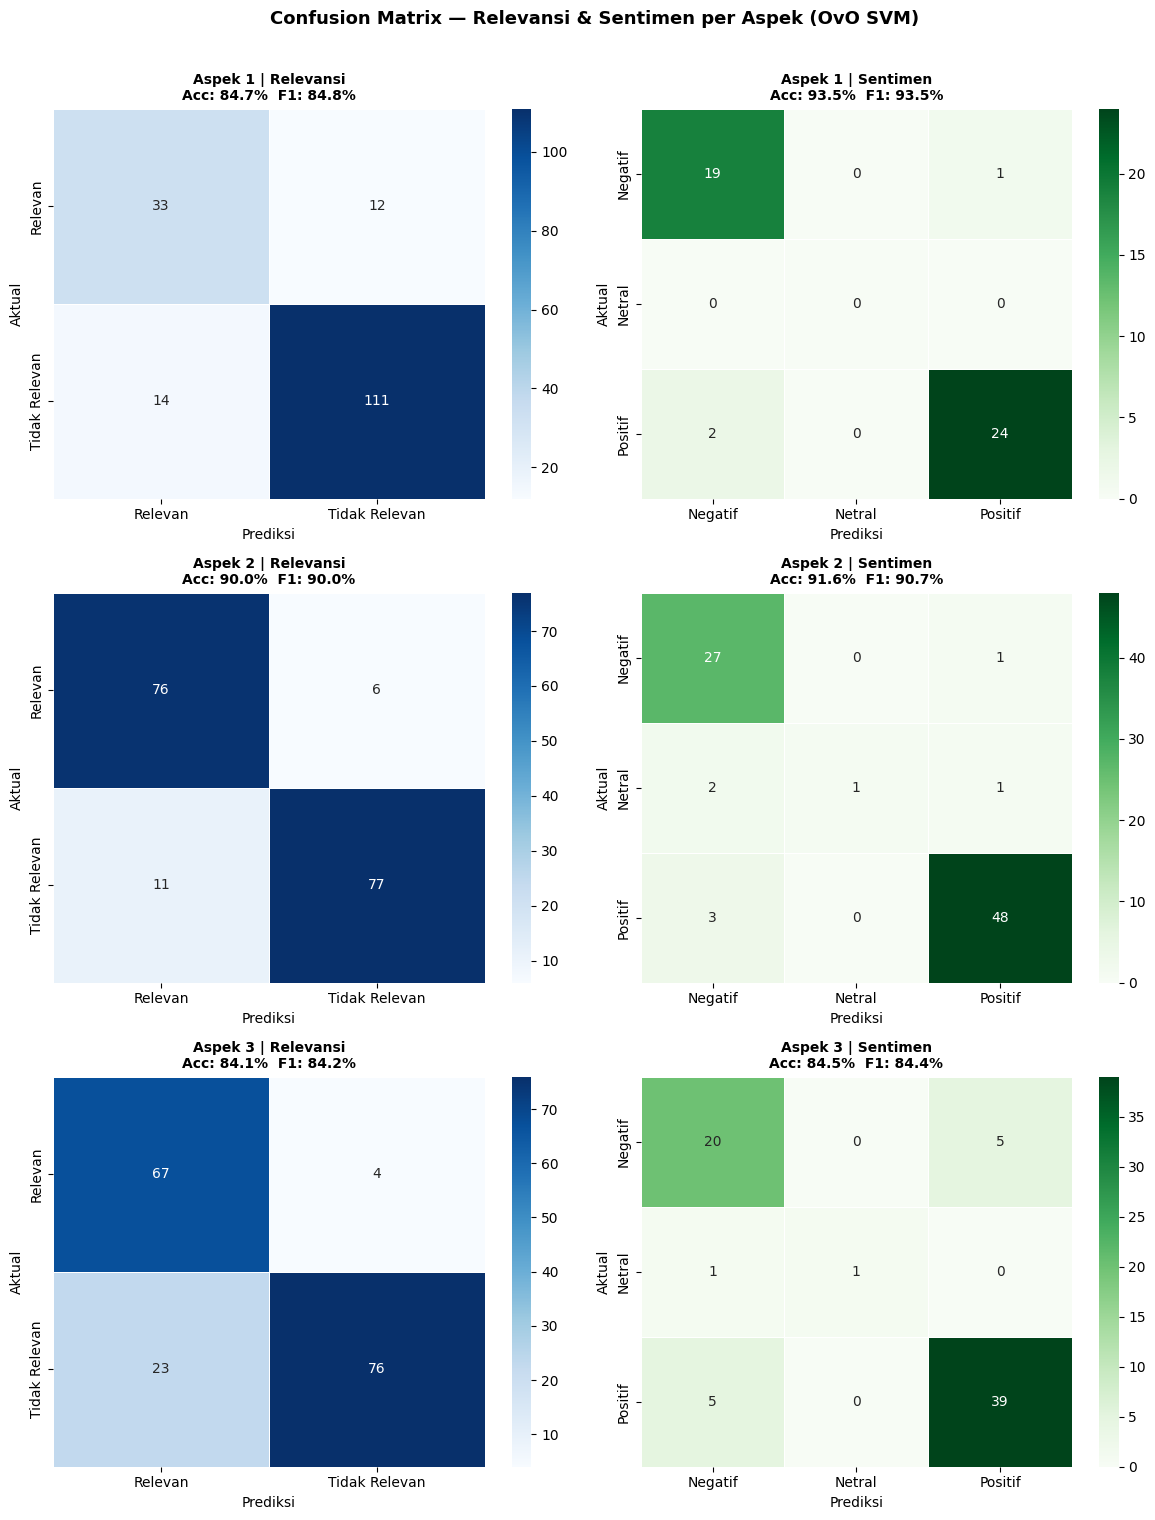

✅ Confusion matrix tersimpan!


In [ ]:
# ── 8. Confusion Matrix ───────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(12, 15))
fig.suptitle('Confusion Matrix — Relevansi & Sentimen per Aspek (OvO SVM)',
             fontsize=13, fontweight='bold', y=1.01)

for row_idx, (aspek, res) in enumerate(pipeline.items()):
    cm_rel = confusion_matrix(res['y_test_rel'], res['y_pred_rel'],
                               labels=res['labels_relevansi'])
    sns.heatmap(cm_rel, annot=True, fmt='d', cmap='Blues',
                xticklabels=res['labels_relevansi'],
                yticklabels=res['labels_relevansi'],
                ax=axes[row_idx][0], linewidths=0.5)
    axes[row_idx][0].set_title(
        f'{aspek} | Relevansi\nAcc: {res["acc_relevansi"]*100:.1f}%  '
        f'F1: {res["f1_relevansi"]*100:.1f}%',
        fontsize=10, fontweight='bold')
    axes[row_idx][0].set_ylabel('Aktual')
    axes[row_idx][0].set_xlabel('Prediksi')

    cm_sen = confusion_matrix(res['y_test_sen'], res['y_pred_sen'],
                               labels=res['labels_sentimen'])
    sns.heatmap(cm_sen, annot=True, fmt='d', cmap='Greens',
                xticklabels=res['labels_sentimen'],
                yticklabels=res['labels_sentimen'],
                ax=axes[row_idx][1], linewidths=0.5)
    axes[row_idx][1].set_title(
        f'{aspek} | Sentimen\nAcc: {res["acc_sentimen"]*100:.1f}%  '
        f'F1: {res["f1_sentimen"]*100:.1f}%',
        fontsize=10, fontweight='bold')
    axes[row_idx][1].set_ylabel('Aktual')
    axes[row_idx][1].set_xlabel('Prediksi')

plt.tight_layout()
plt.savefig('confusion_matrix_ovo.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Confusion matrix tersimpan!')

In [ ]:
def analisis_ulasan(teks):
    """
    Prediksi otomatis aspek + sentimen dari 1 ulasan (FULL MODEL)

    Alur:
      1. Model A → cek relevansi
      2. Jika relevan → Model B → prediksi sentimen
      3. Jika tidak → langsung Tidak Relevan
    """

    teks_stem = apply_stemming(teks)
    hasil     = {}

    for aspek, res in pipeline.items():

        # ─────────────────────────────
        # STEP 1: MODEL ASPEK
        # ─────────────────────────────
        X_rel = res['tfidf_relevansi'].transform([teks_stem])
        relevansi = res['model_relevansi'].predict(X_rel)[0]

        # ─────────────────────────────
        # STEP 2: MODEL SENTIMEN
        # ─────────────────────────────
        if relevansi == 'Relevan':
            X_sen = res['tfidf_sentimen'].transform([teks_stem])
            sentimen = res['model_sentimen'].predict(X_sen)[0]
        else:
            sentimen = '-'

        hasil[aspek] = {
            'relevansi': relevansi,
            'sentimen': sentimen
        }

    # ─────────────────────────────
    # OUTPUT TAMPILAN
    # ─────────────────────────────
    print(f'\n📝 Ulasan : "{teks}"')
    print(f'{"─"*60}')
    print(f'  {"Aspek":<25} {"Relevansi":<18} {"Sentimen"}')
    print(f'  {"─"*25} {"─"*18} {"─"*10}')

    for aspek, out in hasil.items():
        ikon     = '✅' if out['relevansi'] == 'Relevan' else '⬜'
        sentimen = out['sentimen'] if out['relevansi'] == 'Relevan' else 'Tidak Relevan'

        print(f'  {nama_aspek[aspek]:<25} {ikon} {out["relevansi"]:<16} {sentimen}')

    print(f'{"─"*60}')

    return hasil

In [ ]:
analisis_ulasan("aplikasi ga bisa login")


📝 Ulasan : "aplikasi ga bisa login"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ✅ Relevan          Negatif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Negatif'}}

In [ ]:
analisis_ulasan("aplikasinya memudahkan dan pelayanannya sangat baik")


📝 Ulasan : "aplikasinya memudahkan dan pelayanannya sangat baik"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ✅ Relevan          Positif
  Teknis Aplikasi           ✅ Relevan          Positif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Positif'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Positif'}}

In [ ]:
analisis_ulasan("aplikasinya susah")


📝 Ulasan : "aplikasinya susah"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ✅ Relevan          Negatif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Negatif'}}

In [ ]:
analisis_ulasan("dokternya baik sekali")


📝 Ulasan : "dokternya baik sekali"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ✅ Relevan          Positif
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Positif'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("antrian dokter eror")


📝 Ulasan : "antrian dokter eror"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ✅ Relevan          Negatif
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("aplikasinya mudah tetapi layanannya buruk")


📝 Ulasan : "aplikasinya mudah tetapi layanannya buruk"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ✅ Relevan          Positif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Positif'}}

In [ ]:
analisis_ulasan("saat mengambil obat antriannya eror")


📝 Ulasan : "saat mengambil obat antriannya eror"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ✅ Relevan          Negatif
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("untuk aplikasinya bagus sekali tapi untuk susternya sangat buruk")


📝 Ulasan : "untuk aplikasinya bagus sekali tapi untuk susternya sangat buruk"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ✅ Relevan          Positif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Positif'}}

In [ ]:
analisis_ulasan("sumpah dokternya buruk")


📝 Ulasan : "sumpah dokternya buruk"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("temu dokter di persulit")


📝 Ulasan : "temu dokter di persulit"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ✅ Relevan          Negatif
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("jadi mudah untuk booking dokter")


📝 Ulasan : "jadi mudah untuk booking dokter"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ✅ Relevan          Positif
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Relevan', 'sentimen': 'Positif'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("tolong dokternya kalau menjelaskan harus lebih ramah karena selalu pakai nada tinggi")


📝 Ulasan : "tolong dokternya kalau menjelaskan harus lebih ramah karena selalu pakai nada tinggi"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("kenapa si aplikasinya selalu ga bisa di buka tulisannya server not found")


📝 Ulasan : "kenapa si aplikasinya selalu ga bisa di buka tulisannya server not found"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ✅ Relevan          Negatif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Negatif'}}

In [ ]:
analisis_ulasan("sejauh ini mysiloam sangat membantu dalam proses booking dokter tapi dokternya kalau menjelaskan harus lebih ramah karena selalu pakai nada tinggi")


📝 Ulasan : "sejauh ini mysiloam sangat membantu dalam proses booking dokter tapi dokternya kalau menjelaskan harus lebih ramah karena selalu pakai nada tinggi"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ✅ Relevan          Positif
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Relevan', 'sentimen': 'Positif'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("kenapa saat proses antri di aplikasi dan di rumah sakit berbeda")


📝 Ulasan : "kenapa saat proses antri di aplikasi dan di rumah sakit berbeda"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ✅ Relevan          Negatif
  Pelayanan & Kepuasan      ✅ Relevan          Negatif
  Teknis Aplikasi           ⬜ Tidak Relevan    Tidak Relevan
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 2': {'relevansi': 'Relevan', 'sentimen': 'Negatif'},
 'Aspek 3': {'relevansi': 'Tidak Relevan', 'sentimen': '-'}}

In [ ]:
analisis_ulasan("ui/ux sangat user friendly")


📝 Ulasan : "ui/ux sangat user friendly"
────────────────────────────────────────────────────────────
  Aspek                     Relevansi          Sentimen
  ───────────────────────── ────────────────── ──────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan    Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan    Tidak Relevan
  Teknis Aplikasi           ✅ Relevan          Positif
────────────────────────────────────────────────────────────


{'Aspek 1': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 2': {'relevansi': 'Tidak Relevan', 'sentimen': '-'},
 'Aspek 3': {'relevansi': 'Relevan', 'sentimen': 'Positif'}}

# **1 MODEL MULTIASPEK**

In [ ]:
!pip install PySastrawi scikit-learn pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 4.6 MB/s eta 0:00:00


In [ ]:
# ── 2. Import ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, hamming_loss
)

In [ ]:
# ── 2. Load Data ──────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()

filename = 'Labelling_Skripsweet_-_FIX.csv'
df_raw   = pd.read_csv(filename)
print(f'✅ Data dimuat: {df_raw.shape[0]} baris')
print(df_raw[['tanpa_stemming','final_aspek1','final_aspek2','final_aspek3']].head(5))

Saving Labelling_Skripsweet_-_FIX.csv to Labelling_Skripsweet_-_FIX.csv
✅ Data dimuat: 1699 baris
                                      tanpa_stemming final_aspek1  \
0         setiap mau masuk ke beranda selalu loading          NaN   
1                       aplikasi rumah sakit terbaik          NaN   
2  aplikasi lengkap fitur andalan dan sangat info...          NaN   
3               sangat memudahkan terimakasih siloam          NaN   
4                                    mudah dan cepat          NaN   

  final_aspek2 final_aspek3  
0          NaN      Negatif  
1          NaN      Positif  
2          NaN      Positif  
3          NaN      Positif  
4          NaN      Positif  


In [ ]:
# ── 4. Stemming ──────────────────────────────────────────────
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def apply_stemming(text):
    return stemmer.stem(str(text)) if pd.notna(text) else ''

print('\nMenerapkan stemming...')
df_raw['ulasan_stem'] = df_raw['tanpa_stemming'].apply(apply_stemming)
print('✅ Stemming selesai!')


Menerapkan stemming...
✅ Stemming selesai!


In [ ]:
# ── 5. Buat Label Multi-Output ────────────────────────────────
valid_sentimen = ['Positif', 'Negatif', 'Netral']

def buat_label(val):
    return val if val in valid_sentimen else 'Tidak Relevan'

df_raw['label_aspek1'] = df_raw['final_aspek1'].apply(buat_label)
df_raw['label_aspek2'] = df_raw['final_aspek2'].apply(buat_label)
df_raw['label_aspek3'] = df_raw['final_aspek3'].apply(buat_label)

Y = df_raw[['label_aspek1', 'label_aspek2', 'label_aspek3']]

print('\nDistribusi Label per Aspek:')
aspek_names = {
    'label_aspek1': 'Fitur Medis Aplikasi',
    'label_aspek2': 'Pelayanan & Kepuasan',
    'label_aspek3': 'Teknis Aplikasi'
}
for col, nama in aspek_names.items():
    print(f'\n  {nama}:')
    print(f'  {df_raw[col].value_counts().to_dict()}')


Distribusi Label per Aspek:

  Fitur Medis Aplikasi:
  {'Tidak Relevan': 1246, 'Positif': 253, 'Negatif': 198, 'Netral': 2}

  Pelayanan & Kepuasan:
  {'Tidak Relevan': 878, 'Positif': 502, 'Negatif': 280, 'Netral': 39}

  Teknis Aplikasi:
  {'Tidak Relevan': 990, 'Positif': 437, 'Negatif': 253, 'Netral': 19}


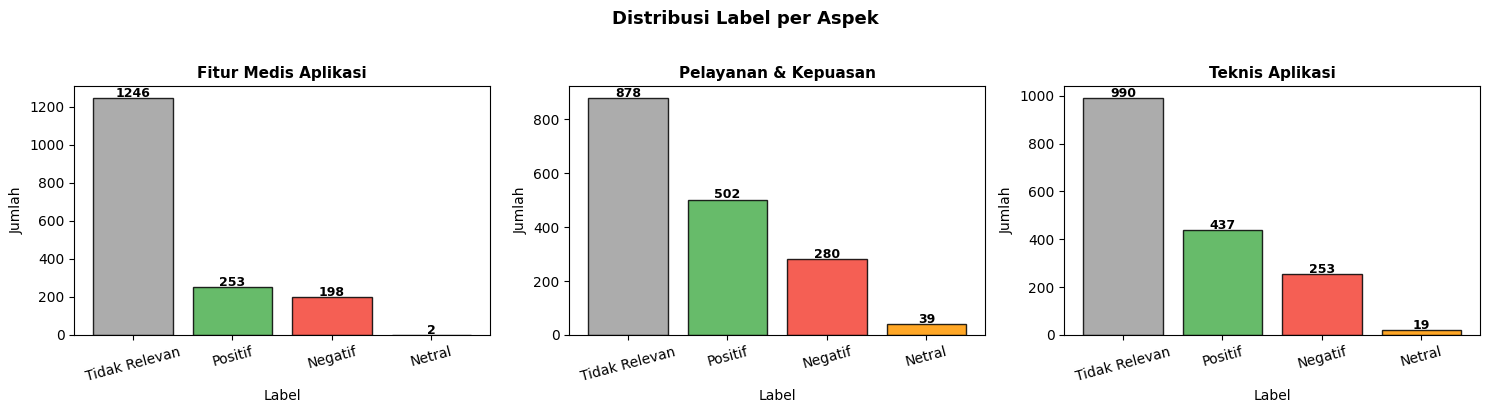

In [ ]:
# ── 6. Visualisasi Distribusi Label ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
color_map = {
    'Positif'      : '#4CAF50',
    'Negatif'      : '#F44336',
    'Netral'       : '#FF9800',
    'Tidak Relevan': '#9E9E9E'
}
for ax, col, nama in zip(axes, aspek_names.keys(), aspek_names.values()):
    counts = df_raw[col].value_counts()
    colors = [color_map.get(l, '#607D8B') for l in counts.index]
    bars   = ax.bar(counts.index, counts.values, color=colors, edgecolor='black', alpha=0.85)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(nama, fontsize=11, fontweight='bold')
    ax.set_xlabel('Label')
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Distribusi Label per Aspek', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 7. Fungsi Training Model ──────────────────────────────────
def train_multilabel_svm(X_raw, Y, nama_model='Model', test_size=0.1, random_state=42):
    """
    Training MultiOutputClassifier + SVM OvO.
    1 model untuk semua aspek sekaligus (multi-label).
    Setiap aspek punya SVM sendiri di dalam MultiOutputClassifier.
    """
    print(f'\n{"="*60}')
    print(f'  TRAINING: {nama_model}')
    print(f'{"="*60}')

    # TF-IDF
    tfidf   = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, min_df=1)
    X_tfidf = tfidf.fit_transform(X_raw)

    # Split 90/10
    X_train, X_test, Y_train, Y_test = train_test_split(
        X_tfidf, Y,
        test_size=test_size,
        random_state=random_state
    )

    print(f'  Total data   : {X_tfidf.shape[0]}')
    print(f'  Data Train   : {X_train.shape[0]} (90%)')
    print(f'  Data Test    : {X_test.shape[0]} (10%)')
    print(f'  Fitur TF-IDF : {X_train.shape[1]}')

    # SVM OvO sebagai base estimator
    svm_base = SVC(
        kernel='linear',
        C=1.0,
        decision_function_shape='ovo',
        random_state=random_state,
        class_weight='balanced'
    )

    # MultiOutputClassifier = 1 SVM per aspek
    model = MultiOutputClassifier(svm_base, n_jobs=-1)
    model.fit(X_train, Y_train)

    # Prediksi
    Y_pred    = model.predict(X_test)
    Y_test_df = Y_test.reset_index(drop=True)
    Y_pred_df = pd.DataFrame(Y_pred, columns=Y.columns)

    # ── Evaluasi per Aspek ────────────────────────────────────
    print(f'\n  {"─"*55}')
    print(f'  {"Aspek":<25} {"Acc":>8} {"Prec":>8} {"Rec":>8} {"F1":>8}')
    print(f'  {"─"*55}')

    summary = []
    for col, nama in aspek_names.items():
        y_true = Y_test_df[col]
        y_pred = Y_pred_df[col]
        acc    = accuracy_score(y_true, y_pred)
        prec   = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1     = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        summary.append({'Aspek': nama, 'Accuracy': acc, 'Precision': prec,
                        'Recall': rec, 'F1-Score': f1})
        print(f'  {nama:<25} {acc*100:>7.2f}% {prec*100:>7.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}%')

       # ── Evaluasi Keseluruhan ──────────────────────────────────
    hl_list = []
    for col in Y_test_df.columns:
        hl_col = hamming_loss(Y_test_df[col], Y_pred_df[col])
        hl_list.append(hl_col)

    hl = np.mean(hl_list)

    avg_acc = np.mean([s['Accuracy']  for s in summary])
    avg_f1  = np.mean([s['F1-Score']  for s in summary])
    avg_pre = np.mean([s['Precision'] for s in summary])
    avg_rec = np.mean([s['Recall']    for s in summary])

    print(f'  {"─"*55}')
    print(f'  {"Rata-rata":<25} {avg_acc*100:>7.2f}% {avg_pre*100:>7.2f}% {avg_rec*100:>7.2f}% {avg_f1*100:>7.2f}%')
    print(f'  {"─"*55}')
    print(f'  Hamming Loss  : {hl:.4f}')
    print(f'  Hamming Score : {(1-hl)*100:.2f}%')

    # ── Classification Report per Aspek ───────────────────────
    print(f'\n  ── Classification Report ──')
    for col, nama in aspek_names.items():
        print(f'\n  [{nama}]')
        print(classification_report(Y_test_df[col], Y_pred_df[col], zero_division=0))

    return {
        'nama'       : nama_model,
        'model'      : model,
        'tfidf'      : tfidf,
        'Y_test'     : Y_test_df,
        'Y_pred'     : Y_pred_df,
        'summary'    : summary,
        'hamming_loss' : hl,
        'avg_acc'    : avg_acc,
        'avg_f1'     : avg_f1,
        'avg_pre'    : avg_pre,
        'avg_rec'    : avg_rec,
    }

In [ ]:
# ── 8. Training Tanpa Stemming & Dengan Stemming ─────────────
hasil_no_stem  = train_multilabel_svm(
    df_raw['tanpa_stemming'], Y, nama_model='Tanpa Stemming'
)
hasil_stem     = train_multilabel_svm(
    df_raw['ulasan_stem'], Y, nama_model='Dengan Stemming'
)
print('\n✅ Semua model selesai ditraining!')


  TRAINING: Tanpa Stemming
  Total data   : 1699
  Data Train   : 1529 (90%)
  Data Test    : 170 (10%)
  Fitur TF-IDF : 5000

  ───────────────────────────────────────────────────────
  Aspek                          Acc     Prec      Rec       F1
  ───────────────────────────────────────────────────────
  Fitur Medis Aplikasi        82.94%   83.53%   82.94%   83.02%
  Pelayanan & Kepuasan        80.00%   83.23%   80.00%   81.26%
  Teknis Aplikasi             82.94%   82.32%   82.94%   82.59%
  ───────────────────────────────────────────────────────
  Rata-rata                   81.96%   83.03%   81.96%   82.29%
  ───────────────────────────────────────────────────────
  Hamming Loss  : 0.1804
  Hamming Score : 81.96%

  ── Classification Report ──

  [Fitur Medis Aplikasi]
               precision    recall  f1-score   support

      Negatif       0.50      0.71      0.59        14
       Netral       0.00      0.00      0.00         1
      Positif       0.78      0.68      0.72   

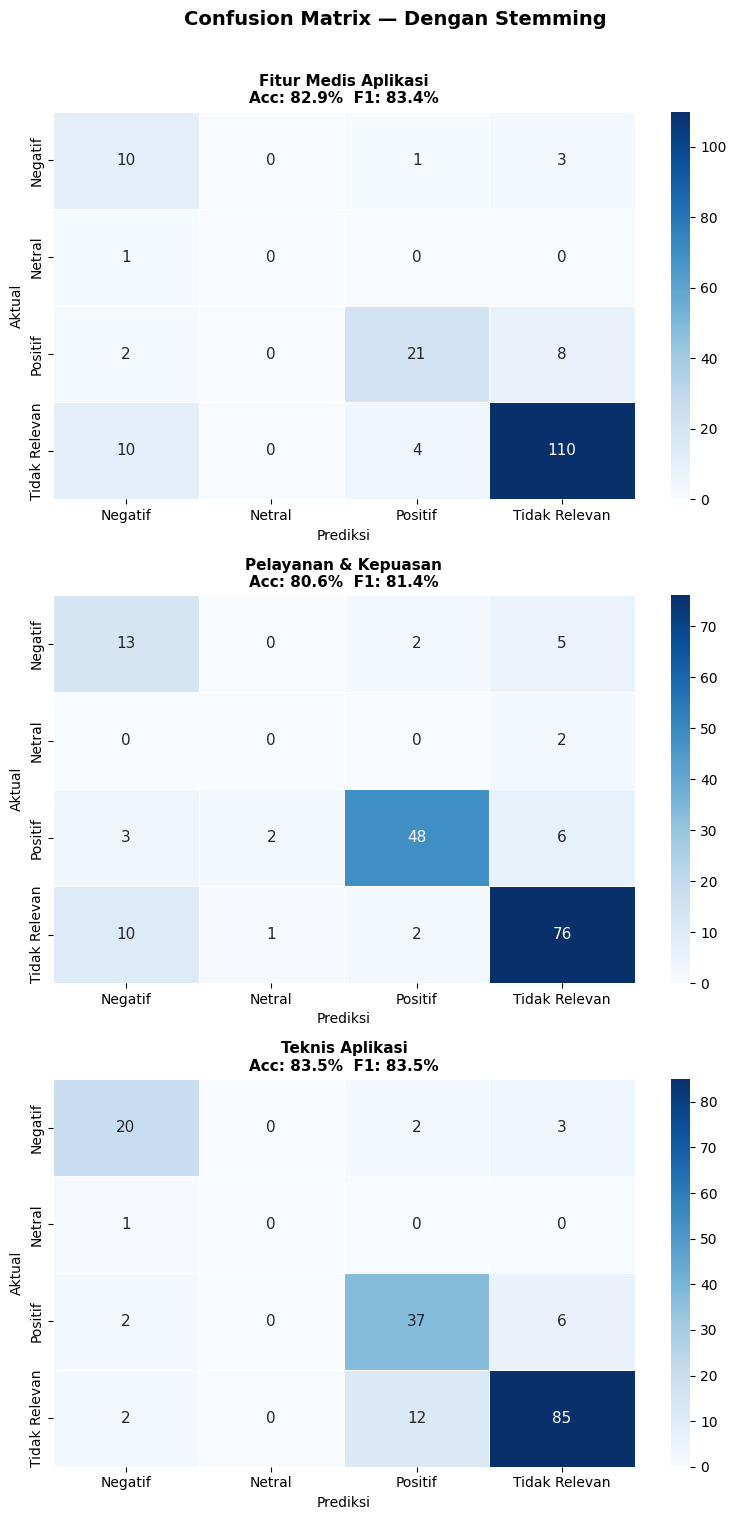

✅ Confusion matrix tersimpan!


In [ ]:
# ── Confusion Matrix — Dengan Stemming ───────────────────────
hasil = hasil_stem  # ✅ pakai yang stemming

Y_test_df = hasil['Y_test']
Y_pred_df = hasil['Y_pred']
nama_model = hasil['nama']

n_aspek = len(aspek_names)
fig, axes = plt.subplots(n_aspek, 1, figsize=(8, 5 * n_aspek))
fig.suptitle(f'Confusion Matrix — {nama_model}',
             fontsize=14, fontweight='bold', y=1.01)

if n_aspek == 1:
    axes = [axes]

for idx, (col, nama) in enumerate(aspek_names.items()):
    y_true        = Y_test_df[col]
    y_pred        = Y_pred_df[col]
    unique_labels = sorted(set(y_true) | set(y_pred))

    cm = confusion_matrix(y_true, y_pred, labels=unique_labels)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_labels,
                yticklabels=unique_labels,
                ax=axes[idx], linewidths=0.5, annot_kws={'size': 11})

    s   = hasil['summary'][idx]
    acc = s['Accuracy']
    f1  = s['F1-Score']

    axes[idx].set_title(
        f'{nama}\nAcc: {acc*100:.1f}%  F1: {f1*100:.1f}%',
        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Aktual', fontsize=10)
    axes[idx].set_xlabel('Prediksi', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_dengan_stemming.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Confusion matrix tersimpan!')

In [ ]:
# ── 12. Fungsi Prediksi Multi-Label ──────────────────────────
def prediksi_ulasan(teks, pakai_stemming=True):
    """
    Input  : 1 ulasan bebas
    Output : prediksi sentimen untuk semua aspek sekaligus
             1 ulasan bisa Relevan di lebih dari 1 aspek (multi-label)
    """
    hasil_model = hasil_stem if pakai_stemming else hasil_no_stem
    teks_input  = apply_stemming(teks) if pakai_stemming else teks
    mode_label  = 'Dengan Stemming 🌿' if pakai_stemming else 'Tanpa Stemming 📄'

    X_input = hasil_model['tfidf'].transform([teks_input])
    y_pred  = hasil_model['model'].predict(X_input)[0]

    hasil = {
        'label_aspek1': y_pred[0],
        'label_aspek2': y_pred[1],
        'label_aspek3': y_pred[2],
    }

    print(f'\n📝 Ulasan : "{teks}"')
    print(f'   Mode    : {mode_label}')
    print(f'{"─"*55}')
    print(f'  {"Aspek":<25} {"Sentimen"}')
    print(f'  {"─"*25} {"─"*15}')
    for col, nama in aspek_names.items():
        sentimen = hasil[col]
        ikon = '✅' if sentimen != 'Tidak Relevan' else '⬜'
        print(f'  {nama:<25} {ikon} {sentimen}')
    print(f'{"─"*55}')
    return hasil

In [ ]:
# ── 13. Test Prediksi ─────────────────────────────────────────
prediksi_ulasan("aplikasi sering error tidak bisa login")
prediksi_ulasan("dokternya ramah dan pelayanannya sangat memuaskan")
prediksi_ulasan("booking dokter mudah tapi aplikasinya lambat saat dibuka")
prediksi_ulasan("aplikasi sangat memudahkan untuk booking dokter tapi dokternya jahat")
prediksi_ulasan("aplikasi ga bisa login tapi dibantu sama susternya bagus sekali")


📝 Ulasan : "aplikasi sering error tidak bisa login"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                     Sentimen
  ───────────────────────── ───────────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan
  Teknis Aplikasi           ✅ Negatif
───────────────────────────────────────────────────────

📝 Ulasan : "dokternya ramah dan pelayanannya sangat memuaskan"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                     Sentimen
  ───────────────────────── ───────────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan
  Pelayanan & Kepuasan      ✅ Positif
  Teknis Aplikasi           ⬜ Tidak Relevan
───────────────────────────────────────────────────────

📝 Ulasan : "booking dokter mudah tapi aplikasinya lambat saat dibuka"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                  

{'label_aspek1': 'Tidak Relevan',
 'label_aspek2': 'Tidak Relevan',
 'label_aspek3': 'Positif'}

In [ ]:
prediksi_ulasan("aplikasi sering error tetapi pelayanan baik")


📝 Ulasan : "aplikasi sering error tetapi pelayanan baik"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                     Sentimen
  ───────────────────────── ───────────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan
  Pelayanan & Kepuasan      ✅ Positif
  Teknis Aplikasi           ✅ Negatif
───────────────────────────────────────────────────────


{'label_aspek1': 'Tidak Relevan',
 'label_aspek2': 'Positif',
 'label_aspek3': 'Negatif'}

In [ ]:
prediksi_ulasan("aplikasi sangat membantu dan dokter sangat ramah")


📝 Ulasan : "aplikasi sangat membantu dan dokter sangat ramah"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                     Sentimen
  ───────────────────────── ───────────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan
  Teknis Aplikasi           ✅ Positif
───────────────────────────────────────────────────────


{'label_aspek1': 'Tidak Relevan',
 'label_aspek2': 'Tidak Relevan',
 'label_aspek3': 'Positif'}

In [ ]:
prediksi_ulasan("aplikasi sangat oke dan pelayanannya sangat ramah")


📝 Ulasan : "aplikasi sangat oke dan pelayanannya sangat ramah"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                     Sentimen
  ───────────────────────── ───────────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan
  Pelayanan & Kepuasan      ✅ Positif
  Teknis Aplikasi           ⬜ Tidak Relevan
───────────────────────────────────────────────────────


{'label_aspek1': 'Tidak Relevan',
 'label_aspek2': 'Positif',
 'label_aspek3': 'Tidak Relevan'}

In [ ]:
prediksi_ulasan("aplikasi sering eror tetapi pelayanan oke")


📝 Ulasan : "aplikasi sering eror tetapi pelayanan oke"
   Mode    : Dengan Stemming 🌿
───────────────────────────────────────────────────────
  Aspek                     Sentimen
  ───────────────────────── ───────────────
  Fitur Medis Aplikasi      ⬜ Tidak Relevan
  Pelayanan & Kepuasan      ⬜ Tidak Relevan
  Teknis Aplikasi           ✅ Negatif
───────────────────────────────────────────────────────


{'label_aspek1': 'Tidak Relevan',
 'label_aspek2': 'Tidak Relevan',
 'label_aspek3': 'Negatif'}

# **EKSPORT MODEL**

In [ ]:
# ── Export Model ke file .pkl ─────────────────────────────────
import pickle
import os

os.makedirs('models', exist_ok=True)

# Simpan pipeline lengkap per aspek
for aspek, res in pipeline.items():
    nama_file = aspek.lower().replace(' ', '_')  # aspek_1, aspek_2, aspek_3

    # Model Relevansi
    with open(f'models/{nama_file}_relevansi.pkl', 'wb') as f:
        pickle.dump({
            'model' : res['model_relevansi'],
            'tfidf' : res['tfidf_relevansi'],
        }, f)

    # Model Sentimen
    with open(f'models/{nama_file}_sentimen.pkl', 'wb') as f:
        pickle.dump({
            'model' : res['model_sentimen'],
            'tfidf' : res['tfidf_sentimen'],
        }, f)

print('✅ Semua model berhasil disimpan!')
print('\nFile yang dihasilkan:')
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f'  📦 {f:<40} ({size:.1f} KB)')

✅ Semua model berhasil disimpan!

File yang dihasilkan:
  📦 aspek_1_sentimen.pkl                     (338.5 KB)
  📦 aspek_1_relevansi.pkl                    (454.2 KB)
  📦 aspek_2_sentimen.pkl                     (356.4 KB)
  📦 aspek_3_relevansi.pkl                    (470.3 KB)
  📦 aspek_3_sentimen.pkl                     (330.1 KB)
  📦 aspek_2_relevansi.pkl                    (431.2 KB)


In [ ]:
# ── Download semua model sekaligus (zip) ─────────────────────
import shutil

# Zip folder models
shutil.make_archive('models_svm_ovo', 'zip', 'models')

# Download
from google.colab import files
files.download('models_svm_ovo.zip')
print('✅ Download selesai!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download selesai!


In [ ]:
# Cek struktur pipeline Model 2
for aspek, res in pipeline.items():
    print(f'\n{aspek}:')
    print(f'  keys: {list(res.keys())}')


Aspek 1:
  keys: ['model_relevansi', 'tfidf_relevansi', 'y_test_rel', 'y_pred_rel', 'acc_relevansi', 'f1_relevansi', 'prec_relevansi', 'rec_relevansi', 'labels_relevansi', 'model_sentimen', 'tfidf_sentimen', 'y_test_sen', 'y_pred_sen', 'acc_sentimen', 'f1_sentimen', 'prec_sentimen', 'rec_sentimen', 'labels_sentimen']

Aspek 2:
  keys: ['model_relevansi', 'tfidf_relevansi', 'y_test_rel', 'y_pred_rel', 'acc_relevansi', 'f1_relevansi', 'prec_relevansi', 'rec_relevansi', 'labels_relevansi', 'model_sentimen', 'tfidf_sentimen', 'y_test_sen', 'y_pred_sen', 'acc_sentimen', 'f1_sentimen', 'prec_sentimen', 'rec_sentimen', 'labels_sentimen']

Aspek 3:
  keys: ['model_relevansi', 'tfidf_relevansi', 'y_test_rel', 'y_pred_rel', 'acc_relevansi', 'f1_relevansi', 'prec_relevansi', 'rec_relevansi', 'labels_relevansi', 'model_sentimen', 'tfidf_sentimen', 'y_test_sen', 'y_pred_sen', 'acc_sentimen', 'f1_sentimen', 'prec_sentimen', 'rec_sentimen', 'labels_sentimen']


In [ ]:
# Cek struktur Model 1
print(hasil_stem.keys())

dict_keys(['nama', 'model', 'tfidf', 'Y_test', 'Y_pred', 'summary', 'hamming_loss', 'avg_acc', 'avg_f1', 'avg_pre', 'avg_rec'])
